# Бейзлайн статьи Wei et al. (2023) — классификация глубины дефектов по TSR (полином 5°) + CNN

Воспроизводим *базовую* линию из статьи
**«A Dataset of Pulsed Thermography for Automated Defect Depth Estimation»**
(Wei, Osman, Valeske, Maldague; *Appl. Sci.* 2023) на её же Kaggle-датасете
`irt-pvc-depth`, но в постановке **классификации кропов** (а не детекции YOLO):

* **вход** — признаки **TSR**: логарифмический полином 5-й степени по фазе остывания,
  его **6 коэффициентов** `a₀…a₅` как каналы `6×H×W` (в статье — препроцессинг TSR);
* **единица классификации** — **кроп вокруг дефекта**, вырезанный по маске;
* **6 классов** глубины: фон + 0.5/1.0/1.5/2.0/2.5 см;
* **бейзлайн-loss** — обычный CrossEntropy (дальше вы будете пробовать другие лоссы).

Данные PVC: ИК-камера FLIR SC5000, 256×320, 10 Гц, 1810 кадров на запись; 38 записей
(`R_*` — прямоугольные дефекты, `Z_*` — круглые). Маски — из CAD-разметки
(`automated_mask`), серые уровни кодируют глубину.

> Это **отправная точка**. Каналы-производные (1-я/2-я) и перебор лоссов —
> отдельные эксперименты поверх этого бейзлайна.


## 1. Импорты и конфигурация

In [22]:
import os, glob, random
import numpy as np
import scipy.io as sio
from scipy import ndimage
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.13.0 | device: cpu


### Константы (всё настраивается здесь)

In [32]:
# ── Пути (автоопределение: датасет мог переехать в datasets/…) ──────────────
from pathlib import Path

KAGGLE_DIR = Path().resolve().parent.parent / "datasets" / "dataset_kaggle"
DATA_DIR   = os.path.join(KAGGLE_DIR, "data")            # R_*.mat / Z_*.mat
MASK_TYPE  = "automated_mask"                            # или "manual_mask"
MASK_DIR   = os.path.join(KAGGLE_DIR, "labels", MASK_TYPE)
print("KAGGLE_DIR:", KAGGLE_DIR)
FEAT_DIR   = Path().resolve().parent.parent / "features_p5"
print(FEAT_DIR)
print("FEAT_DIR:", FEAT_DIR)

# ── Классы: серый уровень маски → класс; класс → глубина, см ─────────────────
GRAY2CLS  = {0:0, 51:1, 102:2, 153:3, 204:4, 255:5}      # 0 = фон
CLS_DEPTH = {1:0.5, 2:1.0, 3:1.5, 4:2.0, 5:2.5}          # см (предположение: 51→0.5 см)
CLASS_NAMES = ["фон","0.5","1.0","1.5","2.0","2.5"]
N_CLASSES = 6

# ── TSR ─────────────────────────────────────────────────────────────────────
POLY_DEGREE = 5                                          # «p5»: 6 коэффициентов
N_CH = POLY_DEGREE + 1                                   # каналов на входе = 6

# ── Кропы ───────────────────────────────────────────────────────────────────
CROP = 48                                                # размер кропа, пикс.
N_BG_PER_VIDEO = 8                                       # фоновых кропов на запись

# ── Обучение ────────────────────────────────────────────────────────────────
N_TEST_VIDEOS = 10                                       # сплит ПО ВИДЕО (без утечки)
BATCH = 64; EPOCHS = 30; LR = 1e-3

# для отладки можно ограничить число видео (None = все 38)
MAX_VIDEOS = None

KAGGLE_DIR: /Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle
/Users/tomatocoder/Documents/thermal-control-ya-project/features_p5
FEAT_DIR: /Users/tomatocoder/Documents/thermal-control-ya-project/features_p5


## 2. Предвычисление TSR-признаков (полином 5°) — один раз, с кэшем на диск

Для каждой записи: находим пик нагрева, берём фазу остывания, переходим к
`(log t, log ΔT)` и аппроксимируем **полиномом 5-й степени** попиксельно
(`numpy.polyfit` векторизуется). Сохраняем тензор коэффициентов `6×H×W` в `features_p5/`.

In [33]:
def list_videos():
    print(DATA_DIR)
    ids = [os.path.splitext(os.path.basename(p))[0]
           for p in glob.glob(os.path.join(DATA_DIR, "*.mat"))]
    print("Найденные видео:", ids)
    ids = sorted(ids)
    return ids if MAX_VIDEOS is None else ids[:MAX_VIDEOS]

def load_mat_stack(vid):
    m = sio.loadmat(os.path.join(DATA_DIR, vid + ".mat"))
    key = next(k for k in ("imageArray","data","IMAGES")
               if k in m and np.asarray(m[k]).ndim == 3)
    d = np.asarray(m[key]).astype(np.float32)            # (H, W, n)
    return np.transpose(d, (2,0,1))                      # (n, H, W)

def tsr_coeffs(X, deg=POLY_DEGREE):
    '''X:(n,H,W) → коэффициенты полинома log ΔT(log t): (deg+1, H, W).'''
    n, H, W = X.shape
    peak = int(np.argmax(X.reshape(n,-1).mean(1)))       # кадр пика нагрева
    base = X[:max(1,peak//4)].mean(0)                    # базовая линия (до нагрева)
    Xc = X[peak:]                                        # фаза остывания
    dT = np.clip(Xc - base[None], 1e-3, None)            # ΔT>0
    tc = (np.arange(Xc.shape[0]) + 1).astype(np.float32) # локальное время (кадры)
    logt = np.log(tc); logdT = np.log(dT).reshape(len(tc), -1)
    coef = np.polyfit(logt, logdT, deg)                  # (deg+1, H*W)
    return coef.reshape(deg+1, H, W).astype(np.float32)

def precompute_features(force=False):
    ids = list_videos()
    for i, vid in enumerate(ids, 1):
        out = os.path.join(FEAT_DIR, vid + ".npy")
        if os.path.exists(out) and not force:
            continue
        X = load_mat_stack(vid)
        C = tsr_coeffs(X)
        np.save(out, C)
        del X, C
        print(f"[{i}/{len(ids)}] {vid} → {out}")
    print("готово, признаки в", FEAT_DIR)

precompute_features()

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']
готово, признаки в /Users/tomatocoder/Documents/thermal-control-ya-project/features_p5


### Проверка каналов на одной записи

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']
['R_002', 'R_003', 'R_004', 'R_005', 'R_006', 'R_007', 'R_008', 'R_009', 'R_010', 'R_011', 'R_012', 'R_013', 'R_014', 'R_015', 'R_016', 'R_017', 'R_018', 'R_019', 'R_020', 'Z_002', 'Z_003', 'Z_004', 'Z_005', 'Z_006', 'Z_007', 'Z_008', 'Z_009', 'Z_010', 'Z_011', 'Z_012', 'Z_013', 'Z_014', 'Z_015', 'Z_016', 'Z_017', 'Z_018', 'Z_019', 'Z_020']
/Users/tomatocoder/Documents/thermal-control-ya-project/features_p5/R_002.npy
тензор признаков: (6, 256, 320) (каналы = коэффициенты a0..a5)


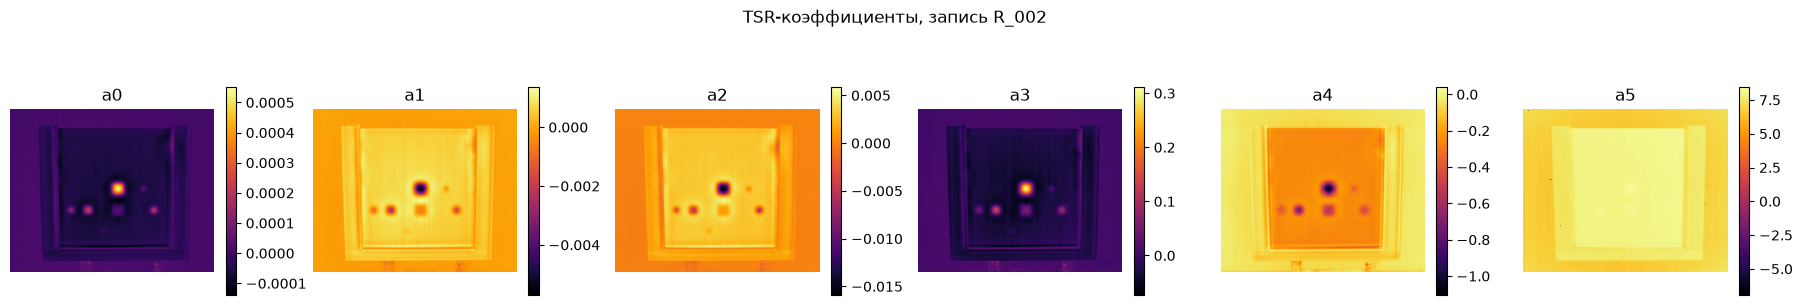

In [34]:
vids = list_videos()
print(vids)
print(os.path.join(FEAT_DIR, vids[0] + ".npy"))
C0 = np.load(os.path.join(FEAT_DIR, vids[0] + ".npy"))
print("тензор признаков:", C0.shape, "(каналы = коэффициенты a0..a5)")
fig, axs = plt.subplots(1, N_CH, figsize=(3*N_CH, 3))
for k in range(N_CH):
    im = axs[k].imshow(C0[k], cmap="inferno"); axs[k].set_title(f"a{k}"); axs[k].axis("off")
    fig.colorbar(im, ax=axs[k], fraction=0.046)
fig.suptitle(f"TSR-коэффициенты, запись {vids[0]}", y=1.05); plt.tight_layout(); plt.show()

## 3. Извлечение кропов по маскам

По маске находим связные области каждого класса глубины → bbox → центрированный
кроп `CROP×CROP`. Дополнительно берём случайные **фоновые** кропы (класс 0).
Формируем индекс `(video_id, r0, c0, class)` — сами пиксели берём лениво из кэша.

In [35]:
def load_mask_cls(vid):
    im = np.array(Image.open(os.path.join(MASK_DIR, vid + ".png")))
    cls = np.zeros_like(im, dtype=np.uint8)
    for g, c in GRAY2CLS.items(): cls[im == g] = c
    return cls

def crop_bounds(r, c, H, W, size=CROP):
    r0 = int(np.clip(r - size//2, 0, H - size))
    c0 = int(np.clip(c - size//2, 0, W - size))
    return r0, c0

def build_index():
    '''Список записей (vid, r0, c0, label) по всем видео.'''
    idx = []
    for vid in list_videos():
        cls = load_mask_cls(vid); H, W = cls.shape
        # дефектные кропы: по одному на связную область
        for c in range(1, N_CLASSES):
            lbl, n = ndimage.label(cls == c)
            for k in range(1, n+1):
                rr, cc = ndimage.center_of_mass(lbl == k)
                r0, c0 = crop_bounds(rr, cc, H, W)
                idx.append((vid, r0, c0, c))
        # фоновые кропы: случайные точки, где вокруг только фон
        bg = (cls == 0)
        ys, xs = np.where(bg[CROP:H-CROP, CROP:W-CROP])
        if len(ys):
            sel = np.random.choice(len(ys), size=min(N_BG_PER_VIDEO, len(ys)), replace=False)
            for s in sel:
                r0, c0 = int(ys[s]+CROP//2), int(xs[s]+CROP//2)
                idx.append((vid, r0, c0, 0))
    return idx

INDEX = build_index()
import collections
cnt = collections.Counter(l for *_, l in INDEX)
print("всего кропов:", len(INDEX))
print("по классам:", {CLASS_NAMES[k]: cnt.get(k,0) for k in range(N_CLASSES)})

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']
всего кропов: 680
по классам: {'фон': 304, '0.5': 86, '1.0': 89, '1.5': 67, '2.0': 65, '2.5': 69}


### Визуальная проверка кропов и меток

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']


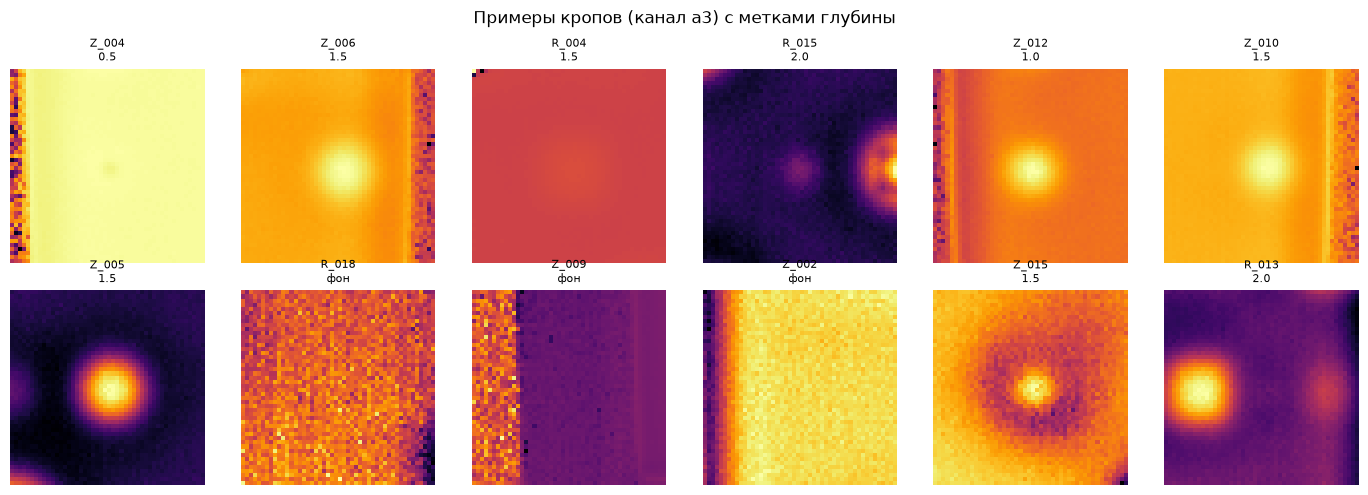

In [36]:
feat_cache = {v: np.load(os.path.join(FEAT_DIR, v + ".npy")) for v in list_videos()}

def get_crop(vid, r0, c0):
    return feat_cache[vid][:, r0:r0+CROP, c0:c0+CROP]

fig, axs = plt.subplots(2, 6, figsize=(14, 5))
sample = random.sample(INDEX, 12)
for ax, (vid, r0, c0, lab) in zip(axs.ravel(), sample):
    ax.imshow(get_crop(vid, r0, c0)[3], cmap="inferno")   # показываем канал a3
    ax.set_title(f"{vid}\n{CLASS_NAMES[lab]}", fontsize=8); ax.axis("off")
fig.suptitle("Примеры кропов (канал a3) с метками глубины"); plt.tight_layout(); plt.show()

## 4. Сплит по видео, нормировка и Dataset

**Сплит строго по записям** (кропы одной записи не попадают и в train, и в test —
иначе утечка). Поканальную нормировку (μ, σ) считаем **только по train**.

In [37]:
all_vids = list_videos()
rng = np.random.default_rng(SEED)
perm = rng.permutation(all_vids)
test_vids  = set(perm[:N_TEST_VIDEOS])
train_vids = set(perm[N_TEST_VIDEOS:])
print(f"train видео: {len(train_vids)} | test видео: {len(test_vids)}")

train_idx = [r for r in INDEX if r[0] in train_vids]
test_idx  = [r for r in INDEX if r[0] in test_vids]

# μ/σ по каналам — по train-кропам
stk = np.stack([get_crop(v,r0,c0) for (v,r0,c0,_) in train_idx])  # (Ntr,C,CROP,CROP)
CH_MEAN = stk.mean(axis=(0,2,3)); CH_STD = stk.std(axis=(0,2,3)) + 1e-6
del stk
print("μ каналов:", np.round(CH_MEAN,3)); print("σ каналов:", np.round(CH_STD,3))

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']
train видео: 28 | test видео: 10
μ каналов: [-0.000e+00  2.000e-03  4.000e-03 -1.200e-01 -4.200e-02  7.532e+00]
σ каналов: [1.000e-03 1.000e-02 3.400e-02 5.560e-01 1.502e+00 1.020e+00]


In [38]:
class CropDataset(Dataset):
    def __init__(self, index, train=False):
        self.index = index; self.train = train
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        vid, r0, c0, lab = self.index[i]
        x = get_crop(vid, r0, c0).astype(np.float32)
        x = (x - CH_MEAN[:,None,None]) / CH_STD[:,None,None]     # нормировка
        if self.train:                                          # аугментация
            if random.random() < 0.5: x = x[:, :, ::-1]
            if random.random() < 0.5: x = x[:, ::-1, :]
            k = random.randint(0, 3); x = np.rot90(x, k, axes=(1,2))
        x = np.ascontiguousarray(x)
        return torch.from_numpy(x), lab

train_ds = CropDataset(train_idx, train=True)
test_ds  = CropDataset(test_idx,  train=False)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=False)
test_ld  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)
xb, yb = next(iter(train_ld)); print("батч:", xb.shape, yb.shape)

батч: torch.Size([64, 6, 48, 48]) torch.Size([64])


## 5. Модель — компактная CNN (вход 6 каналов)

Небольшая свёрточная сеть (3 блока Conv-BN-ReLU + глобальный пулинг + FC).
Своя, без предобучения — для малых данных это честный бейзлайн. Готовый вариант
(timm/ResNet с `in_chans=6`) — в комментарии.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, in_ch=N_CH, n_cls=N_CLASSES):
        super().__init__()
        def block(a, b):
            return nn.Sequential(nn.Conv2d(a, b, 3, padding=1), nn.BatchNorm2d(b),
                                 nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(in_ch,32), block(32,64), block(64,128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, n_cls))
    def forward(self, x): return self.head(self.features(x))

model = SmallCNN().to(DEVICE)
print(model)
print("параметров:", sum(p.numel() for p in model.parameters()))

# Готовый вариант (нужен `pip install timm`):
import timm
model = timm.create_model('resnet18', in_chans=N_CH, num_classes=N_CLASSES,
                          pretrained=True).to(DEVICE)

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   

## 6. Loss — бейзлайн CrossEntropy

Реестр лоссов сделан «фабрикой», чтобы позже менять одной строкой. Для бейзлайна —
обычный CE. (Веса классов под дисбаланс закомментированы — включите в след. экспериментах.)

In [40]:
def make_loss(name="ce"):
    if name == "ce":
        return nn.CrossEntropyLoss()
    if name == "weighted_ce":
        freq = np.array([sum(1 for *_,l in train_idx if l==k) for k in range(N_CLASSES)])
        w = torch.tensor((freq.sum()/(freq+1e-6)), dtype=torch.float32, device=DEVICE)
        return nn.CrossEntropyLoss(weight=w/w.mean())
    if name == "label_smooth":
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    raise ValueError(name)

LOSS_NAME = "ce"                        # ← бейзлайн
criterion = make_loss(LOSS_NAME)
print("loss:", LOSS_NAME)

loss: ce


## 7. Обучение

In [41]:
def run_epoch(loader, train=False):
    model.train(train)
    tot, correct, loss_sum = 0, 0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb); loss = criterion(logits, yb)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item()*len(yb)
            correct += (logits.argmax(1) == yb).sum().item(); tot += len(yb)
    return loss_sum/tot, correct/tot

opt = torch.optim.Adam(model.parameters(), lr=LR)
hist = {"tr_loss":[], "tr_acc":[], "te_loss":[], "te_acc":[]}
for ep in range(1, EPOCHS+1):
    trl, tra = run_epoch(train_ld, train=True)
    tel, tea = run_epoch(test_ld,  train=False)
    hist["tr_loss"].append(trl); hist["tr_acc"].append(tra)
    hist["te_loss"].append(tel); hist["te_acc"].append(tea)
    if ep % 5 == 0 or ep == 1:
        print(f"эпоха {ep:3d}: train loss {trl:.3f} acc {tra:.3f} | test loss {tel:.3f} acc {tea:.3f}")

эпоха   1: train loss 1.728 acc 0.248 | test loss 1.689 acc 0.385
эпоха   5: train loss 1.159 acc 0.547 | test loss 1.389 acc 0.476
эпоха  10: train loss 0.706 acc 0.782 | test loss 0.960 acc 0.668
эпоха  15: train loss 0.429 acc 0.864 | test loss 0.746 acc 0.731
эпоха  20: train loss 0.315 acc 0.903 | test loss 0.515 acc 0.827
эпоха  25: train loss 0.316 acc 0.875 | test loss 0.668 acc 0.779
эпоха  30: train loss 0.212 acc 0.922 | test loss 0.756 acc 0.764


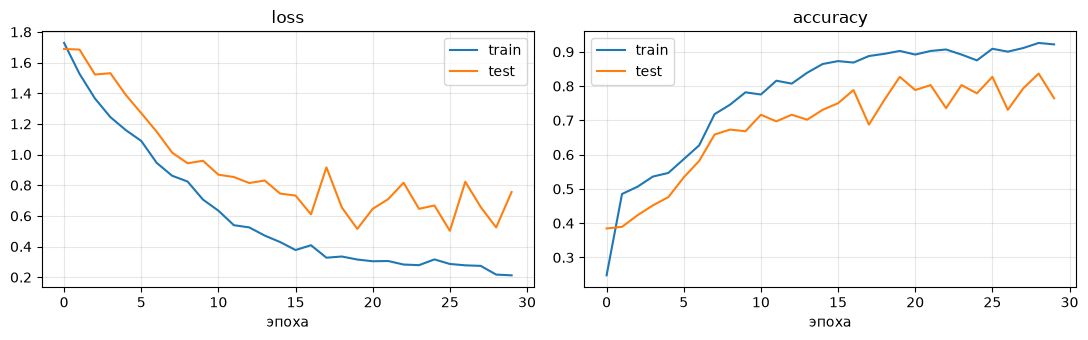

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist["tr_loss"], label="train"); ax[0].plot(hist["te_loss"], label="test")
ax[0].set_title("loss"); ax[0].set_xlabel("эпоха"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist["tr_acc"], label="train"); ax[1].plot(hist["te_acc"], label="test")
ax[1].set_title("accuracy"); ax[1].set_xlabel("эпоха"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Оценка: accuracy, macro-F1, confusion, ординальный MAE

Confusion-матрица — как в статье (Fig. 10): смотрим, путаются ли **соседние** глубины
(это терпимо) или далёкие. Ординальный MAE — средняя ошибка в шагах глубины.

accuracy   : 0.764
macro-F1   : 0.698
ordinal MAE: 0.543 шага глубины


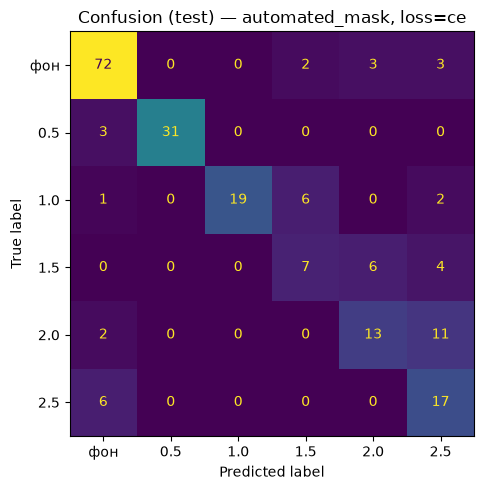

In [43]:
model.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_ld:
        p = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        y_pred.extend(p.tolist()); y_true.extend(yb.numpy().tolist())
y_true, y_pred = np.array(y_true), np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
f1m = f1_score(y_true, y_pred, average="macro")
ord_mae = np.mean(np.abs(y_true - y_pred))        # в шагах класса
print(f"accuracy   : {acc:.3f}")
print(f"macro-F1   : {f1m:.3f}")
print(f"ordinal MAE: {ord_mae:.3f} шага глубины")

cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6,5)); disp.plot(ax=ax, cmap="viridis", colorbar=False)
ax.set_title(f"Confusion (test) — {MASK_TYPE}, loss={LOSS_NAME}"); plt.tight_layout(); plt.show()

## 9. Итоги и что дальше

Это **бейзлайн**: TSR (полином 5°, 6 коэффициентов) → компактная CNN → 6 классов
глубины по кропам, loss = CrossEntropy, честный сплит по видео.

**Сравнение со статьёй.** У Wei et al. лучший результат дал не TSR, а **PPT (фаза)**
(mAP50 0.811 против 0.577 у TSR); их модель — YOLOv5-детекция. Здесь задача проще
(классификация готовых кропов), метрики другие (accuracy/F1/confusion), поэтому числа
напрямую не сравниваются — но confusion-матрица должна показывать ту же картину:
путаница преимущественно между **соседними** глубинами.

**Следующие эксперименты (поверх этого ноутбука):**
1. **Каналы-производные:** добавить 1-ю и 2-ю производные полинома (TSR-derivatives,
   как Seq5/6 Chulkov) → вход `N_CH` больше; параметр уже вынесен.
2. **Лоссы:** `weighted_ce`, `label_smooth`, Focal, class-balanced, **ординальные
   (CORAL/CORN)** — менять через `make_loss` / `LOSS_NAME`, сравнивать confusion и MAE.
3. **PPT-канал:** добавить фазу Фурье как ещё один канал (в статье он был сильнейшим).
4. **k-fold по видео** вместо одного сплита — на 38 записях один сплит шумный.


## 10. Эксперимент 1 — каналы производных (p5 / p5+d1 / p5+d1+d2)

Идея (в духе TSR-производных Chulkov, Seq5/6): к 6 коэффициентам полинома `a₀…a₅`
добавляем коэффициенты его **1-й** и **2-й производных** (по `log t`) как
дополнительные каналы. Сравниваем три входа при одинаковом лоссе (CE):

| режим | каналы |
|---|---|
| `p5` | 6 (только коэффициенты) |
| `p5+d1` | 6 + 5 = 11 |
| `p5+d1+d2` | 6 + 5 + 4 = 15 |

Всё переиспользует уже посчитанный кэш (`feat_cache` = коэффициенты), производные
берутся аналитически — пересчёта `polyfit` нет. Нормировка каналов — по train.

In [ ]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader

EXP_EPOCHS = EPOCHS         # эпох на один прогон в свипах (можно уменьшить для скорости)

def poly_deriv_coeffs(coef, order=1):
    # Производная полинома (коэффициенты highest-first), применённая order раз.
    c = coef
    for _ in range(order):
        D = c.shape[0] - 1                         # текущая степень
        powers = np.arange(D, 0, -1)               # степени при ненулевых членах
        c = c[:-1] * powers.reshape(-1, *([1] * (c.ndim - 1)))
    return c

CHANNEL_MODES = {"p5": (0, 0), "p5+d1": (1, 0), "p5+d1+d2": (1, 1)}

def build_channels(coef6, mode):
    # coef6:(6,H,W) → каналы согласно режиму (коэфф + произв. коэфф).
    d1, d2 = CHANNEL_MODES[mode]
    chans = [coef6]
    if d1: chans.append(poly_deriv_coeffs(coef6, 1))
    if d2: chans.append(poly_deriv_coeffs(coef6, 2))
    return np.concatenate(chans, axis=0).astype(np.float32)   # единый dtype

def n_channels_of(mode):
    dummy = next(iter(feat_cache.values()))[:, :1, :1]
    return build_channels(dummy, mode).shape[0]

print({m: n_channels_of(m) for m in CHANNEL_MODES})

In [ ]:
class ChanDataset(Dataset):
    '''Кропы с произвольным набором каналов и своей нормировкой.'''
    def __init__(self, index, mode, mean, std, train=False):
        self.index, self.mode = index, mode
        self.mean, self.std, self.train = mean, std, train
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        vid, r0, c0, lab = self.index[i]
        x = build_channels(get_crop(vid, r0, c0), self.mode).astype(np.float32)
        x = (x - self.mean[:, None, None]) / self.std[:, None, None]
        if self.train:
            if random.random() < 0.5: x = x[:, :, ::-1]
            if random.random() < 0.5: x = x[:, ::-1, :]
            x = np.rot90(x, random.randint(0, 3), axes=(1, 2))
        return torch.from_numpy(np.ascontiguousarray(x)), lab

def compute_norm(index, mode):
    stk = np.stack([build_channels(get_crop(v, r0, c0), mode) for (v, r0, c0, _) in index])
    mean = stk.mean(axis=(0, 2, 3)).astype(np.float32)
    std  = (stk.std(axis=(0, 2, 3)) + 1e-6).astype(np.float32)
    return mean, std

def run_experiment(mode, loss_name="ce", epochs=None, seed=SEED):
    '''Полный прогон: обучение + оценка для (каналы, лосс). Возврат метрик и модели.'''
    epochs = epochs or EXP_EPOCHS
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    mean, std = compute_norm(train_idx, mode)
    trl = DataLoader(ChanDataset(train_idx, mode, mean, std, train=True),
                     batch_size=BATCH, shuffle=True)
    tel = DataLoader(ChanDataset(test_idx, mode, mean, std, train=False),
                     batch_size=BATCH, shuffle=False)
    net = SmallCNN(in_ch=len(mean), n_cls=N_CLASSES).to(DEVICE)
    crit = make_loss(loss_name)
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    for _ in range(epochs):
        net.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(net(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    net.eval(); yt, yp = [], []
    with torch.no_grad():
        for xb, yb in tel:
            p = net(xb.to(DEVICE)).argmax(1).cpu().numpy()
            yp += p.tolist(); yt += yb.numpy().tolist()
    yt, yp = np.array(yt), np.array(yp)
    return dict(mode=mode, loss=loss_name, n_ch=len(mean),
                acc=accuracy_score(yt, yp),
                f1=f1_score(yt, yp, average="macro"),
                ord_mae=float(np.mean(np.abs(yt - yp))),
                cm=confusion_matrix(yt, yp, labels=list(range(N_CLASSES))),
                y_true=yt, y_pred=yp, model=net)

In [ ]:
# Свип по наборам каналов (лосс фиксирован = CE)
exp1 = []
for mode in CHANNEL_MODES:
    r = run_experiment(mode, loss_name="ce")
    print(f"{mode:10} nch={r['n_ch']:2}  acc={r['acc']:.3f}  macroF1={r['f1']:.3f}  ordMAE={r['ord_mae']:.3f}")
    exp1.append(r)

df1 = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cm", "model")} for r in exp1])
best_mode = df1.sort_values("f1", ascending=False).iloc[0]["mode"]
print("\nЛучший набор каналов по macro-F1:", best_mode)
df1

In [ ]:
# Диаграмма сравнения наборов каналов
x = np.arange(len(df1)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, df1["acc"], w, label="accuracy")
ax.bar(x + w/2, df1["f1"],  w, label="macro-F1")
ax.set_xticks(x); ax.set_xticklabels(df1["mode"])
ax.set_ylabel("метрика"); ax.set_title("Каналы производных: p5 vs p5+d1 vs p5+d1+d2")
for i, m in enumerate(df1["ord_mae"]):
    ax.text(i, 0.02, f"ordMAE={m:.2f}", ha="center", fontsize=8)
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## 11. Эксперимент 2 — сравнение лоссов на лучшем наборе каналов

На лучшем входе из Эксп. 1 (`best_mode`) гоняем разные лоссы. Классы
несбалансированы и упорядочены (глубина — шкала), поэтому смотрим не только accuracy,
но и **macro-F1** и **ординальный MAE**, а также **confusion-матрицы** (как Fig. 10):
путаница соседних глубин допустима, далёких — плохо.

In [ ]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    '''Мультиклассовый Focal loss: упор на трудные/редкие примеры.'''
    def __init__(self, gamma=2.0, weight=None):
        super().__init__(); self.gamma = gamma; self.weight = weight
    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=1)
        ce = F.nll_loss(logp, target, weight=self.weight, reduction="none")
        pt = logp.exp().gather(1, target[:, None]).squeeze(1)
        return ((1 - pt) ** self.gamma * ce).mean()

def make_loss(name="ce"):
    '''Расширенная фабрика лоссов (переопределяет базовую).'''
    freq = np.array([sum(1 for *_, l in train_idx if l == k) for k in range(N_CLASSES)])
    if name == "ce":
        return nn.CrossEntropyLoss()
    if name == "weighted_ce":
        w = torch.tensor(freq.sum() / (freq + 1e-6), dtype=torch.float32, device=DEVICE)
        return nn.CrossEntropyLoss(weight=w / w.mean())
    if name == "label_smooth":
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    if name == "focal":
        return FocalLoss(gamma=2.0)
    if name == "class_balanced":               # веса по «эффективному числу», beta=0.999
        beta = 0.999; eff = 1 - beta ** np.maximum(freq, 1)
        w = (1 - beta) / (eff + 1e-9); w = w / w.mean()
        return nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    raise ValueError(name)

print("лоссы:", ["ce", "weighted_ce", "label_smooth", "focal", "class_balanced"])

In [ ]:
# Свип по лоссам на лучшем наборе каналов
LOSSES = ["ce", "weighted_ce", "label_smooth", "focal", "class_balanced"]
exp2 = []
for ln in LOSSES:
    r = run_experiment(best_mode, loss_name=ln)
    print(f"{ln:14} acc={r['acc']:.3f}  macroF1={r['f1']:.3f}  ordMAE={r['ord_mae']:.3f}")
    exp2.append(r)

df2 = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cm", "model")} for r in exp2])
best_loss = df2.sort_values(["f1", "acc"], ascending=False).iloc[0]["loss"]
print(f"\nЛучший лосс на входе {best_mode}: {best_loss}")
df2

In [ ]:
# Диаграмма сравнения лоссов
x = np.arange(len(df2)); w = 0.28
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w, df2["acc"], w, label="accuracy")
ax.bar(x,      df2["f1"],  w, label="macro-F1")
ax.bar(x + w, df2["ord_mae"]/df2["ord_mae"].max(), w, label="ordMAE (норм.)")
ax.set_xticks(x); ax.set_xticklabels(df2["loss"], rotation=15)
ax.set_title(f"Сравнение лоссов на входе {best_mode}")
ax.set_ylabel("метрика"); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

In [ ]:
# Confusion-матрицы для каждого лосса
fig, axs = plt.subplots(1, len(exp2), figsize=(4*len(exp2), 3.6))
for ax, r in zip(np.atleast_1d(axs), exp2):
    ConfusionMatrixDisplay(r["cm"], display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="viridis", colorbar=False, values_format="d")
    ax.set_title(f"{r['loss']}\nF1={r['f1']:.2f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle(f"Confusion по лоссам (вход {best_mode})", y=1.04)
plt.tight_layout(); plt.show()

## 12. Отдельная проверка: p5 + 1-я + 2-я производная + weighted CE

Целевая конфигурация проекта: **15 каналов** (коэффициенты полинома `a₀…a₅` +
коэффициенты 1-й и 2-й производных) и **взвешенный CrossEntropy** (компенсация
дисбаланса классов). Обучаем на полном числе эпох (`EPOCHS`) и даём полную оценку:
метрики, по-классовый отчёт (precision/recall/F1) и confusion-матрицу.

In [ ]:
from sklearn.metrics import classification_report

res = run_experiment("p5+d1+d2", loss_name="weighted_ce", epochs=EPOCHS)
print(f"вход: p5+d1+d2 ({res['n_ch']} каналов) | loss: weighted_ce | эпох: {EPOCHS}")
print(f"accuracy    : {res['acc']:.3f}")
print(f"macro-F1    : {res['f1']:.3f}")
print(f"ordinal MAE : {res['ord_mae']:.3f} шага глубины\n")
print(classification_report(res["y_true"], res["y_pred"],
      labels=list(range(N_CLASSES)), target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(res["cm"], display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="viridis", colorbar=False, values_format="d")
ax.set_title("p5+d1+d2 + weighted CE — confusion (test)")
plt.tight_layout(); plt.show()

## 13. Эксперимент 3 — PPT (фаза Фурье)

**Pulsed Phase Thermography**: берём БПФ температурной динамики по времени и как
признак используем **фазу** на нескольких низких значимых частотах. В статье Wei et al.
именно PPT дал лучший результат (mAP50 0.811 против 0.577 у TSR).

PPT нельзя вывести из коэффициентов полинома — это независимое преобразование сырого
видео, поэтому фаза считается отдельно и кэшируется в `features_ppt/` (по аналогии с
TSR-кэшем). Сравниваем три входа при взвешенном CE:

| вход | каналы |
|---|---|
| `p5+d1+d2` (TSR-лучший) | 15 |
| **PPT** (только фаза) | `len(PPT_BINS)` |
| `p5+d1+d2 + PPT` | 15 + `len(PPT_BINS)` |

In [60]:
# ── Предвычисление PPT-фазы (кэш features_ppt/) ─────────────────────────────
PPT_BINS = [1, 2, 3]                                   # низкие значимые частоты
PPT_DIR  = FEAT_DIR.parent / "features_ppt"; os.makedirs(PPT_DIR, exist_ok=True)

def ppt_phase(X, bins=PPT_BINS):
    # Фаза БПФ по времени на фазе остывания. Считаем только нужные бины
    # (прямая сумма), чтобы не хранить полный комплексный спектр.
    n, H, W = X.shape
    peak = int(np.argmax(X.reshape(n, -1).mean(1)))
    base = X[:max(1, peak//4)].mean(0)
    dT = (X[peak:] - base[None]).astype(np.float32)    # (nc,H,W)
    nc = dT.shape[0]; t = np.arange(nc)
    out = []
    for k in bins:
        wk = np.exp(-2j*np.pi*k*t/nc)                  # (nc,)
        Fk = np.tensordot(wk, dT, axes=([0],[0]))      # (H,W) комплекс
        out.append(np.angle(Fk))
    return np.stack(out).astype(np.float32)            # (len(bins),H,W)

def precompute_ppt(force=False):
    for i, vid in enumerate(list_videos(), 1):
        out = PPT_DIR / (vid + ".npy")
        if out.exists() and not force: continue
        X = load_mat_stack(vid); np.save(out, ppt_phase(X)); del X
        print(f"[{i}] PPT {vid}")
    print("PPT-признаки в", PPT_DIR)

precompute_ppt()
ppt_cache = {v: np.load(PPT_DIR / (v + ".npy")) for v in list_videos()}
print("каналов PPT:", len(PPT_BINS))

/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/data
Найденные видео: ['Z_018', 'Z_019', 'R_009', 'R_008', 'R_020', 'R_018', 'R_019', 'Z_009', 'Z_020', 'Z_008', 'Z_011', 'Z_005', 'R_003', 'R_017', 'R_016', 'R_002', 'Z_004', 'Z_010', 'Z_006', 'Z_012', 'R_014', 'R_015', 'Z_013', 'Z_007', 'Z_003', 'Z_017', 'R_011', 'R_005', 'R_004', 'R_010', 'Z_016', 'Z_002', 'Z_014', 'R_006', 'R_012', 'R_013', 'R_007', 'Z_015']
[13] PPT R_014
[14] PPT R_015
[15] PPT R_016
[16] PPT R_017
[17] PPT R_018
[18] PPT R_019
[19] PPT R_020
[20] PPT Z_002
[21] PPT Z_003
[22] PPT Z_004
[23] PPT Z_005
[24] PPT Z_006
[25] PPT Z_007
[26] PPT Z_008
[27] PPT Z_009
[28] PPT Z_010
[29] PPT Z_011
[30] PPT Z_012
[31] PPT Z_013
[32] PPT Z_014
[33] PPT Z_015
[34] PPT Z_016
[35] PPT Z_017
[36] PPT Z_018
[37] PPT Z_019
[38] PPT Z_020
PPT-признаки в /Users/tomatocoder/Documents/thermal-control-ya-project/features_ppt
/Users/tomatocoder/Documents/thermal-control-ya-project/datasets/dataset_kaggle/d

In [70]:
# ── Датасет и прогон с опциональными TSR- и PPT-каналами ────────────────────
def get_ppt_crop(vid, r0, c0):
    return ppt_cache[vid][:, r0:r0+CROP, c0:c0+CROP]

def build_channels_ext(vid, r0, c0, mode, use_ppt):
    parts = []
    if mode is not None:                               # TSR-каналы (p5[/+d1/+d2])
        parts.append(build_channels(get_crop(vid, r0, c0), mode))
    if use_ppt:                                        # + PPT-фаза
        parts.append(get_ppt_crop(vid, r0, c0).astype(np.float32))
    return np.concatenate(parts, axis=0).astype(np.float32)

def compute_norm_ext(index, mode, use_ppt):
    stk = np.stack([build_channels_ext(v, r0, c0, mode, use_ppt) for (v, r0, c0, _) in index])
    return stk.mean(axis=(0,2,3)).astype(np.float32), (stk.std(axis=(0,2,3))+1e-6).astype(np.float32)

class ChanDatasetExt(Dataset):
    def __init__(self, index, mode, use_ppt, mean, std, train=False):
        self.index, self.mode, self.use_ppt = index, mode, use_ppt
        self.mean, self.std, self.train = mean, std, train
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        vid, r0, c0, lab = self.index[i]
        x = build_channels_ext(vid, r0, c0, self.mode, self.use_ppt)
        x = (x - self.mean[:, None, None]) / self.std[:, None, None]
        if self.train:
            if random.random() < 0.5: x = x[:, :, ::-1]
            if random.random() < 0.5: x = x[:, ::-1, :]
            x = np.rot90(x, random.randint(0, 3), axes=(1, 2))
        return torch.from_numpy(np.ascontiguousarray(x)), lab

def run_experiment_ext(mode, use_ppt, loss_name="weighted_ce", epochs=None, seed=SEED):
    epochs = 60
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    mean, std = compute_norm_ext(train_idx, mode, use_ppt)
    trl = DataLoader(ChanDatasetExt(train_idx, mode, use_ppt, mean, std, True),
                     batch_size=BATCH, shuffle=True)
    tel = DataLoader(ChanDatasetExt(test_idx, mode, use_ppt, mean, std, False),
                     batch_size=BATCH, shuffle=False)
    net = SmallCNN(in_ch=len(mean), n_cls=N_CLASSES).to(DEVICE)
    net = timm.create_model('resnet18', in_chans=len(mean), num_classes=N_CLASSES, pretrained=True).to(DEVICE)
    crit = make_loss(loss_name); opt = torch.optim.Adam(net.parameters(), lr=LR)
    for _ in range(30):
        net.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(net(xb), yb); opt.zero_grad(); loss.backward(); opt.step()
    net.eval(); yt, yp = [], []
    with torch.no_grad():
        for xb, yb in tel:
            yp += net(xb.to(DEVICE)).argmax(1).cpu().numpy().tolist(); yt += yb.numpy().tolist()
    yt, yp = np.array(yt), np.array(yp)
    return dict(name=("PPT" if mode is None else mode) + ("+PPT" if (use_ppt and mode) else ""),
                n_ch=len(mean), acc=accuracy_score(yt, yp),
                f1=f1_score(yt, yp, average="macro"),
                ord_mae=float(np.mean(np.abs(yt-yp))),
                cm=confusion_matrix(yt, yp, labels=list(range(N_CLASSES))))

In [71]:
# Сравнение: TSR-лучший vs PPT vs TSR+PPT (loss = weighted_ce)
configs = [("p5+d1+d2", False), (None, True), ("p5+d1+d2", True)]
configs = [("p5+d1+d2", True)]
exp3 = [run_experiment_ext(m, p, loss_name="weighted_ce") for (m, p) in configs]
for r in exp3:
    print(f"{r['name']:14} nch={r['n_ch']:2}  acc={r['acc']:.3f}  macroF1={r['f1']:.3f}  ordMAE={r['ord_mae']:.3f}")
df3 = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"} for r in exp3])
df3

p5+d1+d2+PPT   nch=18  acc=0.803  macroF1=0.784  ordMAE=0.553


,name,n_ch,acc,f1,ord_mae
0,p5+d1+d2+PPT,18,0.802885,0.783899,0.552885


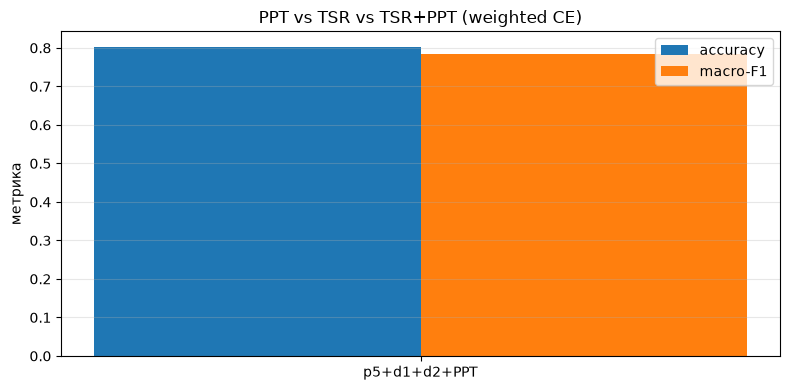

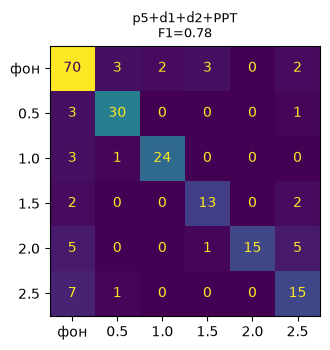

In [72]:
# Диаграмма + confusion для трёх входов
x = np.arange(len(df3)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, df3["acc"], w, label="accuracy")
ax.bar(x + w/2, df3["f1"],  w, label="macro-F1")
ax.set_xticks(x); ax.set_xticklabels(df3["name"]); ax.set_ylabel("метрика")
ax.set_title("PPT vs TSR vs TSR+PPT (weighted CE)")
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, len(exp3), figsize=(4*len(exp3), 3.6))
for ax, r in zip(np.atleast_1d(axs), exp3):
    ConfusionMatrixDisplay(r["cm"], display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="viridis", colorbar=False, values_format="d")
    ax.set_title(f"{r['name']}\nF1={r['f1']:.2f}", fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 14. Итоги экспериментов

- **Эксп. 1 (каналы).** Сравнили `p5` / `p5+d1` / `p5+d1+d2`. Ожидание: добавление
  производных (TSR-derivatives) улучшает разделимость по глубине, как в статье Chulkov
  (Seq5/6 были лучшими). Лучший набор → `best_mode`.
- **Эксп. 2 (лоссы).** На `best_mode` перебрали CE / weighted-CE / label-smoothing /
  Focal / class-balanced. Дисбаланс и ординальность классов — там, где взвешенные и
  Focal-лоссы обычно поднимают macro-F1 и уменьшают путаницу соседних глубин.
- **Эксп. 3 (PPT).** Добавили фазу Фурье отдельно и в комбинации с TSR. В статье
  Wei et al. PPT была сильнейшим препроцессингом — проверяем, повторяется ли это на
  кроп-классификации и даёт ли `TSR+PPT` прирост.

Дальше можно: (1) добавить **ординальные** лоссы (CORAL/CORN), (2) варьировать
`PPT_BINS`/добавить амплитуду Фурье, (3) перейти к **k-fold по видео** для устойчивой
оценки на 38 записях.